# 0. Feature engineering z geometrii IFC — krok po kroku

Tu sobie rozkładam na czynniki pierwsze, jak z surowej siatki trójkątów (mesh)
jednego elementu IFC wyliczam kolejne cechy geometryczne i konstrukcyjne —
dokładnie to, co w pipeline'ie (`01_build_dataset.ipynb`) dzieje się w jednym
wywołaniu `extract_features()` z `src/feature_engineering.py`. Tutaj rozbijam
to na kroki, na czterech przykładowych elementach (Beam, Slab, Stair, Wall),
żeby widzieć *co* liczę i *po co*.

Cała logika siedzi w dwóch modułach, importowanych niżej:
- `src/ifc_geometry.py` — wczytanie siatki, objętość, pole powierzchni, PCA, convex hull
- `src/feature_engineering.py` — cechy zbudowane na tych podstawach

In [1]:
import sys
from pathlib import Path

import ifcopenshell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from ifc_geometry import (
    get_single_element, load_mesh, triangle_areas, surface_area, signed_volume,
    convex_hull_volume_area, convex_hull_area_2d, convex_hull_perimeter_2d,
    pca_axes, project_onto_axes, cross_section_profile,
)
from feature_engineering import extract_features

DATA_DIR = ROOT / "data" / "raw" / "IFCNetCoreIFC"

# jeden reprezentatywny plik z train/ dla kazdej klasy
EXAMPLES = {}
for cls in ["IfcBeam", "IfcSlab", "IfcStair", "IfcWall"]:
    EXAMPLES[cls] = sorted((DATA_DIR / cls / "train").glob("*.ifc"))[0]
EXAMPLES

{'IfcBeam': WindowsPath('C:/Users/agata/OneDrive/Desktop/Test/ifc_test/data/raw/IFCNetCoreIFC/IfcBeam/train/001b165474224004852eb66107868b63.ifc'),
 'IfcSlab': WindowsPath('C:/Users/agata/OneDrive/Desktop/Test/ifc_test/data/raw/IFCNetCoreIFC/IfcSlab/train/0011d9bdd3104fb18472722b861b1a52.ifc'),
 'IfcStair': WindowsPath('C:/Users/agata/OneDrive/Desktop/Test/ifc_test/data/raw/IFCNetCoreIFC/IfcStair/train/00bdbd0a8d3847fcac9d2d77afec1152.ifc'),
 'IfcWall': WindowsPath('C:/Users/agata/OneDrive/Desktop/Test/ifc_test/data/raw/IFCNetCoreIFC/IfcWall/train/0069251196454d22a05991b0b2bce669.ifc')}

## Krok 1 — wczytanie geometrii elementu

`ifcopenshell.geom` zamienia reprezentację IFC (SweptSolid, Brep, CSG, ...) na
triangulowaną siatkę we współrzędnych świata (`USE_WORLD_COORDS=True`), więc
nie obchodzi mnie później, jaką reprezentacją posłużył się program źródłowy
(Tekla, Revit, ...). Sprawdzam to na przykładzie belki (`IfcBeam`).

In [2]:
beam_path = EXAMPLES["IfcBeam"]
f = ifcopenshell.open(str(beam_path))
element = get_single_element(f)
mesh = load_mesh(element)

print("plik:", beam_path.name)
print("zapisany typ w pliku IFC:", element.is_a())
print("liczba wierzcholkow (n_vertices):", mesh.verts.shape[0])
print("liczba trojkatow (n_faces):", mesh.faces.shape[0])

plik: 001b165474224004852eb66107868b63.ifc
zapisany typ w pliku IFC: IfcBeam
liczba wierzcholkow (n_vertices): 302
liczba trojkatow (n_faces): 616


## Krok 2 — pole, objętość, convexity

Pole powierzchni to po prostu suma pól trójkątów siatki. Objętość liczę
twierdzeniem o dywergencji (suma "podpisanych" objętości czworościanów
rozpiętych między każdym trójkątem a początkiem układu) — działa dla
dowolnej zamkniętej (watertight) siatki, więc nie ma znaczenia, czy oryginał
był SweptSolid, Brep czy CSG.

In [3]:
area = surface_area(mesh)
volume = abs(signed_volume(mesh))
hull_volume, hull_area = convex_hull_volume_area(mesh.verts)

print(f"pole powierzchni:      {area:.4f} m2")
print(f"objetosc:               {volume:.4f} m3")
print(f"objetosc otoczki wypuklej (convex hull): {hull_volume:.4f} m3")
print(f"convexity = objetosc/hull = {volume/hull_volume:.3f}  (1.0 = bryla w pelni wypukla)")

pole powierzchni:      40.7187 m2
objetosc:               1.2611 m3
objetosc otoczki wypuklej (convex hull): 2.3586 m3
convexity = objetosc/hull = 0.535  (1.0 = bryla w pelni wypukla)


## Krok 3 — bounding box i PCA, czyli własne osie elementu

Zwykły bounding box (osiowo-wyrównany, X/Y/Z) zależy od tego, jak element
jest obrócony w modelu — bez sensu do porównywania belki poziomej ze skośną.
Zamiast tego liczę **PCA (analizę składowych głównych)** na współrzędnych
wierzchołków: dostaję 3 wzajemnie prostopadłe osie "własne" bryły,
posortowane od najdłuższej (`L1`) do najkrótszej (`L3`) — niezależnie od
orientacji elementu w przestrzeni.

In [4]:
axes, extents = pca_axes(mesh.verts)
L1, L2, L3 = extents
print(f"L1 (najdluzszy wymiar, np. dlugosc belki): {L1:.4f} m")
print(f"L2 (srodkowy wymiar):                       {L2:.4f} m")
print(f"L3 (najkrotszy wymiar, np. grubosc):        {L3:.4f} m")
print()
print("wektory wlasne (kolumny = kierunki osi L1, L2, L3):")
print(np.round(axes, 3))

L1 (najdluzszy wymiar, np. dlugosc belki): 7.7139 m
L2 (srodkowy wymiar):                       1.0119 m
L3 (najkrotszy wymiar, np. grubosc):        0.3332 m

wektory wlasne (kolumny = kierunki osi L1, L2, L3):
[[ 0.001  1.    -0.019]
 [ 1.    -0.001  0.   ]
 [-0.    -0.019 -1.   ]]


## Krok 4 — smukłość konstrukcyjna (slenderness)

Klasyczna smukłość pręta/belki w mechanice budowli to λ = L / i, gdzie `i`
to promień bezwładności przekroju (`i = sqrt(I/A)`, dla przekroju kołowego
upraszcza się do `sqrt(A/π)`). Nie mam tu jawnego przekroju parametrycznego
(to tylko siatka trójkątów), więc szacuję go z objętości, zakładając że
element jest w przybliżeniu pryzmatyczny wzdłuż swojej najdłuższej osi:

```
A_przekroju ≈ objętość / L1
i ≈ sqrt(A_przekroju / π)
λ = L1 / i
```

Im większe λ, tym element "smuklejszy" (bardziej podatny na wyboczenie) —
typowa belka stalowa ma λ rzędu kilkunastu-kilkudziesięciu.

In [5]:
equiv_area = volume / L1
equiv_i = np.sqrt(equiv_area / np.pi)
slenderness = L1 / equiv_i

print(f"rownowazny przekroj poprzeczny A ~ {equiv_area:.6f} m2")
print(f"rownowazny promien bezwladnosci i ~ {equiv_i:.6f} m")
print(f"smuklosc lambda = L1 / i = {slenderness:.2f}")

rownowazny przekroj poprzeczny A ~ 0.163479 m2
rownowazny promien bezwladnosci i ~ 0.228116 m
smuklosc lambda = L1 / i = 33.82


## Krok 5 — kształt 3D: linearity / planarity / sphericity

To rodzina cech znana z klasyfikacji chmur punktów LiDAR (dimensionality
features): stosunki `L1/L2/L3` mówią, czy bryła jest smukła jak pręt
(linearity), płaska jak płyta (planarity), czy bryłowata jak kostka
(sphericity). Te trzy współczynniki sumują się do ~1 — to takie trzy
"archetypy" kształtu.

In [6]:
linearity = 1 - L2 / L1
planarity = (L2 - L3) / L1
sphericity = L3 / L1

print(f"linearity_index  (~1 = pret):   {linearity:.3f}")
print(f"planarity_index  (~1 = plyta):  {planarity:.3f}")
print(f"sphericity_index (~1 = bryla):  {sphericity:.3f}")
print(f"suma: {linearity + planarity + sphericity:.3f}")

linearity_index  (~1 = pret):   0.869
planarity_index  (~1 = plyta):  0.088
sphericity_index (~1 = bryla):  0.043
suma: 1.000


## Krok 6 — cechy "grawitacyjne" (globalne Z = prawdziwy pion)

PCA nic nie wie o grawitacji, ale współrzędne światowe IFC zawsze mają oś Z
skierowaną w górę. Dzięki temu mogę policzyć cechy odpowiadające wprost na
pytania architektoniczne: "czy element stoi pionowo (ściana), czy leży
poziomo (strop/belka), czy jest pochyły (schody)?" — `incline_angle_deg` to
kąt między najdłuższą osią elementu (L1) a płaszczyzną poziomą.

In [7]:
UP = np.array([0.0, 0.0, 1.0])
incline_deg = np.degrees(np.arcsin(np.clip(abs(axes[:, 0] @ UP), 0, 1)))

xy = mesh.verts[:, :2]
footprint_area = convex_hull_area_2d(xy)
footprint_perimeter = convex_hull_perimeter_2d(xy)
footprint_compactness = 4 * np.pi * footprint_area / footprint_perimeter**2
vertical_extent = mesh.verts[:, 2].max() - mesh.verts[:, 2].min()

print(f"kat nachylenia glownej osi wzgledem poziomu: {incline_deg:.1f} deg  (0=lezy, 90=stoi)")
print(f"rzut poziomy (footprint) - pole:       {footprint_area:.3f} m2")
print(f"rzut poziomy (footprint) - obwod:      {footprint_perimeter:.3f} m")
print(f"footprint_compactness (1=zwarty, ~0=wydluzony pasek): {footprint_compactness:.3f}")
print(f"rozpietosc pionowa (Z):                {vertical_extent:.3f} m")

kat nachylenia glownej osi wzgledem poziomu: 0.0 deg  (0=lezy, 90=stoi)
rzut poziomy (footprint) - pole:       7.579 m2
rzut poziomy (footprint) - obwod:      17.193 m
footprint_compactness (1=zwarty, ~0=wydluzony pasek): 0.322
rozpietosc pionowa (Z):                0.315 m


## Krok 7 — regularność przekroju wzdłuż długości (łapanie schodów)

Belka, słup czy kawałek ściany mają (w przybliżeniu) **stały przekrój** na
całej długości — to typowe dla elementów pryzmatycznych/wyciąganych
(extruded). Schody nie: przekrój "pulsuje" z każdym stopniem. Żeby to
złapać, tnę chmurę punktów na plastry wzdłuż osi L1 i w każdym plastrze
mierzę rozstaw punktów w pozostałych dwóch osiach
(`cross_section_profile`) — współczynnik zmienności (CV = odchylenie std /
średnia) tego profilu jest wysoki dla schodów, a bliski zeru dla
elementów pryzmatycznych.

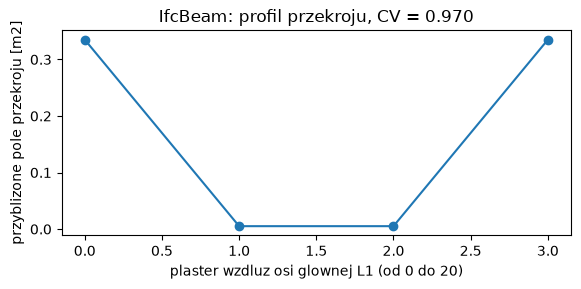

In [8]:
profile = cross_section_profile(mesh.verts, axes, n_bins=20)
cv = profile.std() / profile.mean() if len(profile) > 1 else 0.0

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(profile, marker="o")
ax.set_xlabel("plaster wzdluz osi glownej L1 (od 0 do 20)")
ax.set_ylabel("przyblizone pole przekroju [m2]")
ax.set_title(f"IfcBeam: profil przekroju, CV = {cv:.3f}")
fig.tight_layout()
plt.show()

## Wizualizacja 3D — siatka + osie własne, dla wszystkich czterech klas

Niżej to samo (siatka mesh + strzałki L1/L2/L3 rozciągnięte od środka
ciężkości) dla jednego przykładu z każdej klasy — gołym okiem widać różnicę
między prętowym beam, płaskim slab, pochyłym stair i pionową wall.

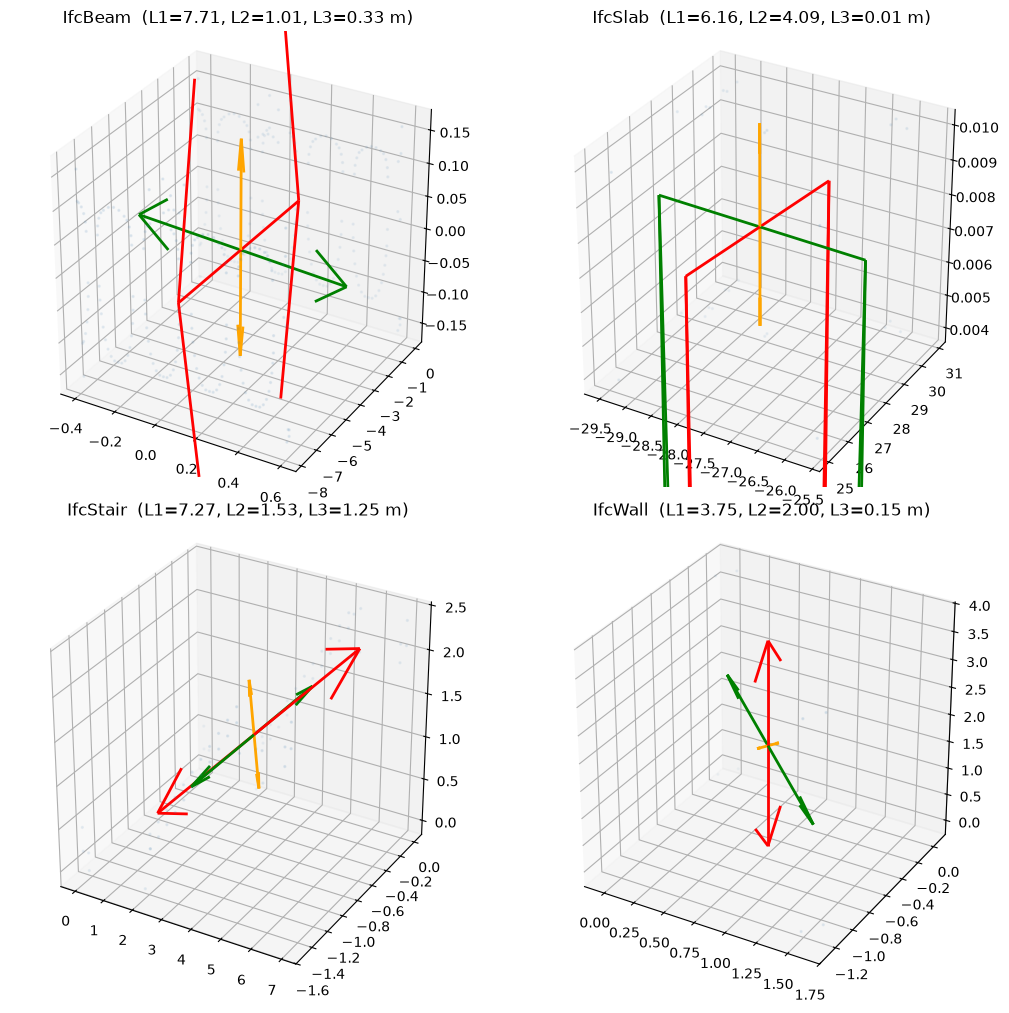

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(11, 10))
for i, cls in enumerate(["IfcBeam", "IfcSlab", "IfcStair", "IfcWall"]):
    f = ifcopenshell.open(str(EXAMPLES[cls]))
    el = get_single_element(f)
    m = load_mesh(el)
    ax_pca, ext = pca_axes(m.verts)
    centroid = m.verts.mean(axis=0)

    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    pts = m.verts
    if len(pts) > 3000:
        idx = np.random.default_rng(0).choice(len(pts), 3000, replace=False)
        pts = pts[idx]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2, alpha=0.35, color="steelblue")

    colors = ["red", "green", "orange"]
    for k in range(3):
        d = ax_pca[:, k] * ext[k] / 2
        ax.quiver(*centroid, *d, color=colors[k], linewidth=2)
        ax.quiver(*centroid, *(-d), color=colors[k], linewidth=2)

    ax.set_title(f"{cls}  (L1={ext[0]:.2f}, L2={ext[1]:.2f}, L3={ext[2]:.2f} m)")
    ax.set_box_aspect([1, 1, 1])

fig.tight_layout()
plt.show()

## Podsumowanie — pełna tabela cech dla czterech przykładów

To dokładnie to, co robi `extract_features()` w jednym wywołaniu (patrz
`src/feature_engineering.py`) — tu widzę wszystkie cechy naraz, dla jednego
reprezentatywnego elementu z każdej klasy, żeby ocenić "na oko" które z nich
rozróżniają klasy najwyraźniej. Pełne porównanie na całym zbiorze (i
faktyczne rankingi ważności cech z Random Forest) są w
`02_train_classifiers.ipynb`.

In [10]:
rows = []
for cls in ["IfcBeam", "IfcSlab", "IfcStair", "IfcWall"]:
    f = ifcopenshell.open(str(EXAMPLES[cls]))
    el = get_single_element(f)
    m = load_mesh(el)
    feats = extract_features(m)
    feats = {"label": cls.replace("Ifc", ""), **feats}
    rows.append(feats)

summary = pd.DataFrame(rows).set_index("label")
interesting_cols = [
    "pca_L1_m", "pca_L2_m", "pca_L3_m", "slenderness_ratio",
    "linearity_index", "planarity_index", "sphericity_index",
    "incline_angle_deg", "verticality_ratio", "footprint_compactness",
    "convexity", "cross_section_area_cv", "step_count_proxy",
]
summary[interesting_cols].T

label,Beam,Slab,Stair,Wall
pca_L1_m,7.713858,6.158735e+00,7.272767,3.750000
pca_L2_m,1.011941,4.094800e+00,1.530086,2.000000
pca_L3_m,0.333222,6.000000e-03,1.254088,0.150000
slenderness_ratio,33.815513,7.827624e+01,16.056526,12.135162
linearity_index,0.868815,3.351232e-01,0.789614,0.466667
planarity_index,0.087987,6.639026e-01,0.037949,0.493333
sphericity_index,0.043198,9.742261e-04,0.172436,0.040000
incline_angle_deg,0.000680,2.712240e-19,20.484831,90.000000
verticality_ratio,0.040836,9.742261e-04,0.339124,1.875000
footprint_compactness,0.322184,7.736248e-01,0.457270,0.203889


**Co widać w tabeli:**
- `incline_angle_deg` i `verticality_ratio` niemal idealnie rozdzielają Wall
  (pionowa, ~90°) od Beam/Slab (poziome, ~0°); Stair wypada gdzieś pośrodku.
- `slenderness_ratio` jest wyraźnie najwyższa dla Beam.
- `planarity_index` jest wysoka dla Slab i Wall (oba są "płytowe"), ale
  `verticality_ratio`/`incline_angle_deg` je rozróżnia.
- `convexity` i `step_count_proxy` łapią niewypukłość i schodkowość
  charakterystyczną dla Stair.

Pełny zbiór cech dla wszystkich 1378 elementów budowany jest w
`01_build_dataset.ipynb` (wywołanie `extract_features()` w pętli po
plikach), a trening modeli w `02_train_classifiers.ipynb`.